<h2 style="text-align:center; color:#1F618D; font-size:30px; font-family:Georgia; font-weight:bold;">
🏠 House Price Prediction Using Machine Learning
</h2>

<hr style="border:1px solid #D6DBDF;">

<h3 style="color:#1F618D; font-family:'Book Antiqua'; font-weight:bold;">
📌 Project Overview
</h3>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">

<b>This project focuses on predicting house prices using Machine Learning techniques.</b> 
The dataset contains multiple housing-related features such as <b>property quality, 
living area, garage capacity, basement area, and total rooms.</b>

</p>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
The primary objective of this project is to:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>Analyze housing data</b></li>
<li><b>Preprocess the dataset</b></li>
<li><b>Perform feature engineering</b></li>
<li><b>Build regression models for accurate prediction</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
Several machine learning algorithms including:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>Linear Regression</b></li>
<li><b>Decision Tree Regressor</b></li>
<li><b>Random Forest Regressor</b></li>
<li><b>Gradient Boosting Regressor</b></li>
<li><b>Support Vector Regressor (SVR)</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
were trained and evaluated using performance metrics such as:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>R2 Score</b></li>
<li><b>Mean Absolute Error (MAE)</b></li>
<li><b>Root Mean Squared Error (RMSE)</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
Finally, the <b>best-performing model</b> was selected based on prediction accuracy and model performance.
</p>

<p style="font-size:16px; font-family:'Cambria';">
<b>Insight:</b> Proper preprocessing, feature selection, and regression modeling significantly improved house price prediction accuracy.
</p>

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 1:</b> 📥 Import Libraries
</h2>

<p style="font-size:16px; font-family:'Cambria';">
In this section, all required libraries for data handling, visualization, preprocessing, model building, and evaluation are imported. 
Pandas and NumPy are used for data manipulation, while Matplotlib and Seaborn are used for visualization. 
Scikit-learn is used for machine learning tasks.
</p>

<p style="font-family:'Cambria'; font-size:16px;">
<b>Insight:</b> Importing libraries at the beginning ensures a smooth and organized workflow.
</p>

In [7]:
# --- Suppress warnings ---
import warnings
warnings.filterwarnings("ignore")

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display graphs inside notebook ---
%matplotlib inline

# --- Model selection & validation ---
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler,LabelEncoder

# --- Pipeline ---
from sklearn.pipeline import Pipeline

# --- Regression Models ---
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# --- Feature selection ---
from sklearn.feature_selection import SelectKBest, f_regression

# --- Evaluation metrics ---
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("✅ All regression libraries imported Successfully")

✅ All regression libraries imported Successfully


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 2:</b> 📊 Load Dataset
</h2>

In [8]:
# Load dataset

df = pd.read_csv("../dataset/data.csv")

print("\n✅ Dataset Loaded Sucessfully")

# Display dataset overview
print("\nDataset Overview")
print("-"*30)
print(f"Dataset Shape   : {df.shape}")

print("\nDaset Information")
print("-"*30)
print(df.info())

print("\nDATA TYPES")
print("-"*30)
print(df.dtypes)

print("\nDESCRIPTIVE STATISTICS")
print("-"*30)
print(df.describe())

print("Insight: The dataset contains both numerical and categorical features affecting house prices.")


✅ Dataset Loaded Sucessfully

Dataset Overview
------------------------------
Dataset Shape   : (1460, 81)

Daset Information
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-nu

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 3:</b> Handling Missing Values
</h2>

In [9]:
# --- Check Missing Values ---

print("\nMissing Values")
print("-"*30)

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

# --- Handling Missing Values ---

print("\nHandling Missing Values")
print("-"*35)

# --- Numerical Columns ---

num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

# --- Categorical Columns ---

cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# --- Verify Missing Values ---

print("\nRemaining Missing Values :",
      df.isnull().sum().sum())

print("\nInsight: Missing values were successfully handled using median and mode techniques.")


Missing Values
------------------------------
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

Handling Missing Values
-----------------------------------

Remaining Missing Values : 0

Insight: Missing values were successfully handled using median and mode techniques.


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 4:</b> Target Variable Distribution
</h2>


Target Variable Distribution
------------------------------


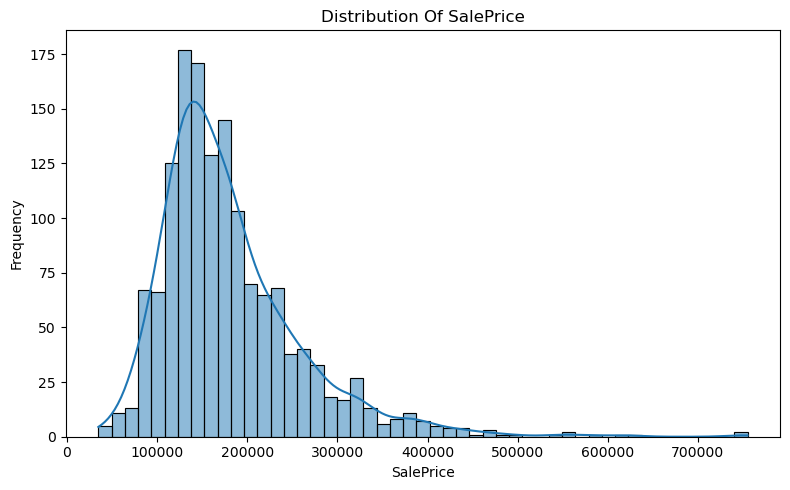

Insight: SalePrice distribution is positively skewed with a few high-value outliers.


In [10]:
print("\nTarget Variable Distribution")
print("-"*30)

plt.figure(figsize=(8,5))

sns.histplot(
    df['SalePrice'],
    kde=True
)

plt.title("Distribution Of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Insight: SalePrice distribution is positively skewed with a few high-value outliers.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 5:</b> Outlier Detection
</h2>


Outlier Detection
------------------------------


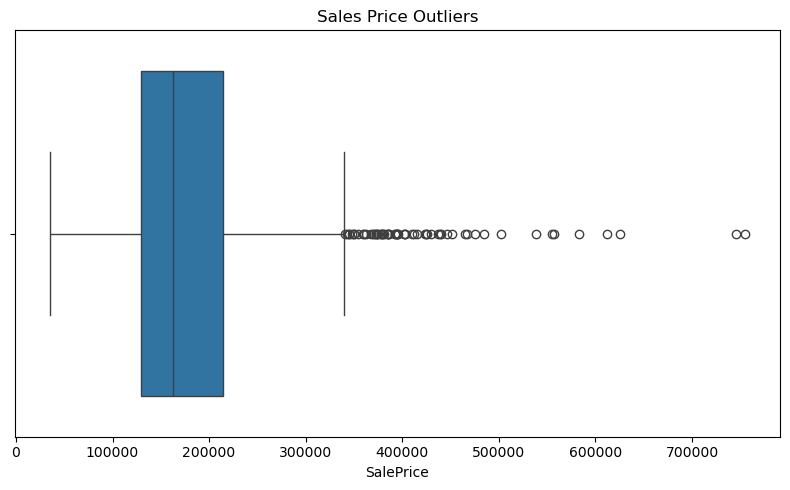

Insight: Outliers were detected in the SalePrice column.


In [11]:
print("\nOutlier Detection")
print("-"*30)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['SalePrice']
)

plt.title("Sales Price Outliers")

plt.tight_layout()
plt.show()

print("Insight: Outliers were detected in the SalePrice column.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 6:</b> Remove Outlier
</h2>


Removing Outliers
--------------------
Dataset Shape after removing Outliers: (1399, 81)

Boxplot After Removing Outliers
-----------------------------------


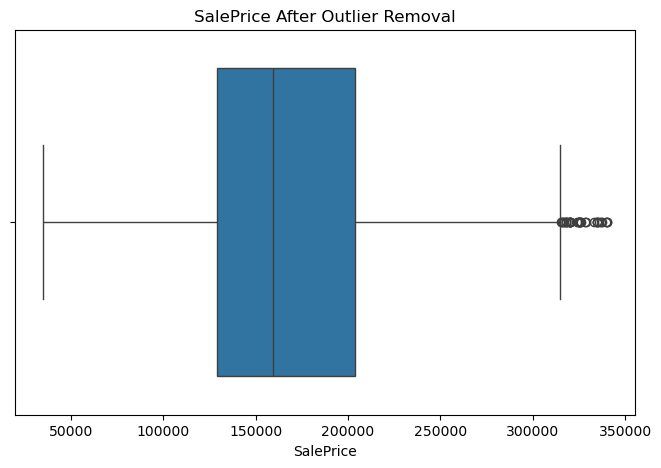

Insight: Most extreme outliers were successfully removed from the dataset.


In [12]:
print("\nRemoving Outliers")
print("-"*20)

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['SalePrice'] >= lower) &
    (df['SalePrice'] <= upper)
]

print(f"Dataset Shape after removing Outliers: {df.shape}")


# --- Boxplot After Removing Outliers ---

print("\nBoxplot After Removing Outliers")
print("-"*35)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['SalePrice']
)

plt.title("SalePrice After Outlier Removal")

plt.show()

print("Insight: Most extreme outliers were successfully removed from the dataset.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 7:</b> Encode Categorical Features
</h2>

In [13]:
df_corr = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(
        df_corr[col]
    )

print("✅ Encoding Completed Successfully")

print("\nInsight: Categorical features were encoded into numerical values for machine learning.")

✅ Encoding Completed Successfully

Insight: Categorical features were encoded into numerical values for machine learning.


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 8:</b> Correlation Analysis
</h2>

In [ ]:
print("\nCorrelation Analysis")
print("-"*30)

corr_matrix = df_corr.corr()

plt.figure(figsize=(20,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.2
)

plt.title("Correlation Matrix")

# Save Heatmap
plt.savefig("../images/correlation_heatmap.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Insight: OverallQual, GrLivArea, and GarageCars strongly influence house prices.")


Correlation Analysis
------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'images/correlation_heatmap.png'

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 9:</b> Top Feature Affecting Price
</h2>

In [ ]:
corr = corr_matrix['SalePrice'].sort_values(ascending=False)

print("\nTop Feature Affecting House Price")
print("-"*40)
print(corr.head(10))

# --- Top Feature Heat Map ---

print("\nTop Feature Heat Map")
print("-"*25)

top_features = corr.index[1:11]

plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Top Feature Correlation")

# Save Heatmap
plt.savefig("images/top_feature_heatmap.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 10:</b> Important Feature Visualization
</h2>

In [ ]:
print("\nFeature Visualization")
print("-"*30)

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)

plt.title("Living Area vs SalePrice")

# Save Plot
plt.savefig("images/regression_plot.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Insight: Houses with larger living areas generally have higher sale prices.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 11:</b> Feature Reduction
</h2>

In [ ]:
print("\nFeature Reduction")
print("-"*20)

top_features = corr.index[1:21]

df_reduced = df_corr[
    top_features.tolist() + ['SalePrice']
]

print(f"Reduced Dataset Shape:{df_reduced.shape}")

print("\nInsight: Feature reduction helped decrease model complexity and improve efficiency.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 12:</b> Feature & Target Split, Feature Scaling
</h2>

In [ ]:
# --- Feature & Target Split ---

X = df_reduced.drop('SalePrice', axis=1)

y = df_reduced['SalePrice']

# --- Feature Scaling ---

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling Completed Sucessfully")

print("\nInsight: Feature scaling standardized the dataset for better model performance.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 13:</b> Feature Selection
</h2>

In [ ]:
print("\nFEATURE SELECTION")
print("-"*20)

selector = SelectKBest(
    score_func=f_regression,
    k=15
)

X_selected = selector.fit_transform(
    X_scaled,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features)

print("\nInsight: SelectKBest selected the most relevant features for prediction.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 14:</b> Train Test Split
</h2>

In [ ]:
print("\nTrain Test Split")
print("-"*20)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nInsight: The dataset was split into training and testing sets for evaluation.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 15:</b> Model Building
</h2>

In [ ]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(),

    "Random Forest":
        RandomForestRegressor(),

    "Gradient Boosting":
        GradientBoostingRegressor(),

    "SVR":
        SVR()
}

results = {}


for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(
        y_test,
        pred
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    # Store results
    results[name] = r2

    # Print Results
    print(f"\n{name}")
    print("-"*20)

    print("R2 Score :", round(r2, 4))
    print("MAE      :", round(mae, 2))
    print("RMSE     :", round(rmse, 2))

print("\nInsight: Multiple regression models were trained and evaluated successfully.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 16:</b> Cross Validation
</h2>

In [ ]:
print("\nCross Validation")
print("-"*20)

rf = RandomForestRegressor()

scores = cross_val_score(
    rf,
    X_selected,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores")
print(scores)

print("\nAverage CV Score")
print(scores.mean())

print("\nInsight: Cross validation confirmed the stability of the model.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 17:</b> Hyperparameter Tuning
</h2>

In [ ]:
print("\nHyperparameter Tuning")
print("-"*30)

params = {

    'n_estimators': [100],

    'max_depth': [10, 15],

    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    params,
    cv=3,
    scoring='r2'
)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters")
print(grid.best_params_)

print("\nBest Score")
print(grid.best_score_)

print("\nInsight: Hyperparameter tuning optimized Random Forest performance.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 18:</b> Actual Vs Predicted Graph
</h2>

In [ ]:
best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred
)

plt.title("Actual Vs Predicted Prices")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Save Plot
plt.savefig("images/actual_vs_predicted.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Insight: Predicted house prices closely matched actual prices.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 19:</b> Model Comparison Table
</h2>

In [ ]:
print("\nModel Comparison")
print("-"*20)

comparison = pd.DataFrame({
    'Model': results.keys(),
    'R2 Score': results.values()
})

comparison = comparison.sort_values(
    by='R2 Score',
    ascending=False
)

print(comparison)

# --- Final Accuracy Graph ---

comparison.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=45)

# Save Plot
plt.savefig("images/model_comparison.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Insight: Random Forest achieved the highest R2 Score and delivered the best prediction performance.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 20:</b> Feature Importance
</h2>

In [ ]:
print("\nFeature Importance")
print("-"*20)

# Train model
rf.fit(
    X_train,
    y_train
)

# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
)

# Plot
plt.figure(figsize=(8,6))

importance.nlargest(10).plot(
    kind='barh'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

# Save Plot
plt.savefig("images/feature_importance.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

print("Insight: OverallQual and GrLivArea were identified as the most important features.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 21:</b> Best Model
</h2>

In [ ]:
best_model = max(
    results,
    key=results.get
)

print("\nBEST MODEL")
print("-"*10)

print("Best Performing Model :", best_model)

print("\nInsight: Random Forest was selected as the final best-performing model.")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 22:</b> Final Insights
</h2>

In [ ]:
print("\nFinal Insights")
print("-"*20)

print("""
1. OverallQual strongly impacts SalePrice.

2. GrLivArea has strong positive correlation
   with house prices.

3. GarageCars and TotalBsmtSF significantly
   affect property value.

4. Random Forest achieved the best
   prediction performance.

5. Feature selection improved model efficiency.

6. Data preprocessing and outlier removal
   improved overall model accuracy.
""")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 23:</b> Customer Suggestions
</h2>

In [ ]:
print("\nCustomer Suggestions")
print("-"*20)

print("""
- Prefer houses with high OverallQual.

- Larger living areas provide better resale value.

- Houses with larger garages are more valuable.

- Recently renovated houses are better investments.

- Basement area and total rooms should be checked
  before purchasing a property.
""")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 24:</b> Challenges Faced
</h2>

In [ ]:
print("\nChallenges Faced")
print("-"*20)

print("""
1. Handling missing values in multiple columns.

2. Encoding categorical variables for machine learning.

3. Managing high dimensionality in the dataset.

4. Detecting and removing outliers.

5. Selecting the best regression model.

6. Preventing overfitting while improving accuracy.
""")

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 25:</b> Final Conclusion
</h2>

In [ ]:
print("\nFinal Conclusion")
print("-"*20)

print("""
The project successfully predicted house prices
using machine learning techniques.

Random Forest Regressor achieved the best
performance based on the highest R2 Score.

OverallQual, GrLivArea, and GarageCars were
identified as the most important features.

The final model can effectively estimate
house prices based on property characteristics.
""")

print("\n✅ PROJECT COMPLETED SUCCESSFULLY")